In [1]:
## Import All the Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler

In [2]:
## Donload the transaction_cleaned.csv file from Athens(AWS) and read it into a pandas DataFrame
credit_card = pd.read_csv("transaction_cleaned.csv")

In [3]:
credit_card.head()

,idx,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,source,age
0,876399,2019-12-21 17:11:55,3531129874770000,fraud_Boyer PLC,shopping_net,3.05,Shelby,Mitchell,F,974 Cindy Stream,...,5895,"Scientist, marine",1975-07-13,5061434ab8c2fb16445eef44526a131e,1356109915,43.825612,-73.305426,0,NaN,51
1,876400,2019-12-21 17:12:10,30235438713303,fraud_Rolfson-Kunde,personal_care,1.13,James,Baldwin,M,3603 Mitchell Court,...,5512,Exhibition designer,1980-03-24,fb02924adc4e3854c979632409093f34,1356109930,39.073415,-81.791111,0,NaN,46
2,876401,2019-12-21 17:12:35,4952583804639909,fraud_Schmeler-Howe,personal_care,4.15,Patricia,Rodriguez,F,386 Randolph Throughway,...,75903,Magazine features editor,1957-04-05,93cf7aa1f91035a23e3ccf9637e1ddc5,1356109955,41.476146,-81.746005,0,NaN,69
3,876406,2019-12-21 17:13:28,4908846471916297,fraud_Botsford Ltd,shopping_pos,3.93,Lauren,Torres,F,03030 White Lakes,...,5875,"Radiographer, therapeutic",1992-07-24,06339722b505812500e5373ff1b1e930,1356110008,32.235207,-96.523176,0,NaN,34
4,876407,2019-12-21 17:13:45,30551643947183,"fraud_Berge, Kautzer and Harris",personal_care,81.05,Morgan,Smith,F,1441 Bradley Place,...,5621,Toxicologist,1973-11-14,522c593a927242c3d77971afe53efe21,1356110025,35.600054,-81.345251,0,NaN,52


In [4]:
credit_card.drop(columns = 'source')


,idx,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age
0,876399,2019-12-21 17:11:55,3531129874770000,fraud_Boyer PLC,shopping_net,3.05,Shelby,Mitchell,F,974 Cindy Stream,...,-73.0882,5895,"Scientist, marine",1975-07-13,5061434ab8c2fb16445eef44526a131e,1356109915,43.825612,-73.305426,0,51
1,876400,2019-12-21 17:12:10,30235438713303,fraud_Rolfson-Kunde,personal_care,1.13,James,Baldwin,M,3603 Mitchell Court,...,-81.8900,5512,Exhibition designer,1980-03-24,fb02924adc4e3854c979632409093f34,1356109930,39.073415,-81.791111,0,46
2,876401,2019-12-21 17:12:35,4952583804639909,fraud_Schmeler-Howe,personal_care,4.15,Patricia,Rodriguez,F,386 Randolph Throughway,...,-80.8164,75903,Magazine features editor,1957-04-05,93cf7aa1f91035a23e3ccf9637e1ddc5,1356109955,41.476146,-81.746005,0,69
3,876406,2019-12-21 17:13:28,4908846471916297,fraud_Botsford Ltd,shopping_pos,3.93,Lauren,Torres,F,03030 White Lakes,...,-97.2351,5875,"Radiographer, therapeutic",1992-07-24,06339722b505812500e5373ff1b1e930,1356110008,32.235207,-96.523176,0,34
4,876407,2019-12-21 17:13:45,30551643947183,"fraud_Berge, Kautzer and Harris",personal_care,81.05,Morgan,Smith,F,1441 Bradley Place,...,-81.4552,5621,Toxicologist,1973-11-14,522c593a927242c3d77971afe53efe21,1356110025,35.600054,-81.345251,0,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,201298,2020-08-31 05:20:49,630469040731,"fraud_Raynor, Feest and Miller",gas_transport,73.56,Meredith,Ayala,F,7107 Henderson Station,...,-121.8686,1288,Barrister,1936-05-01,04e484fcfc61303363bf834a8ff83147,1377926449,46.317122,-122.779059,0,90
1852390,201299,2020-08-31 05:21:03,6595970453799027,fraud_Auer-West,shopping_net,1.94,Gina,Gomez,F,72030 Shelton Crossing Apt. 742,...,-74.4968,2307,Science writer,1969-09-11,69f4967034cfbeba1f50ed642363700e,1377926463,40.034660,-73.719766,0,56
1852391,201300,2020-08-31 05:21:11,30230540139182,fraud_Bruen-Yost,misc_pos,36.30,Hayden,Sanders,M,8465 Reed Green Suite 559,...,-76.8575,645,Orthoptist,1974-05-18,1d60fc4e1abfe8a1187498afd213bac0,1377926471,40.856032,-77.081995,0,52
1852392,201301,2020-08-31 05:21:13,2296006538441789,"fraud_Casper, Hand and Zulauf",grocery_pos,59.60,Judy,Hogan,F,4970 Michelle Burgs,...,-73.9798,2504700,Medical sales representative,1999-09-01,b5edaaa3f54a9fca3159a18621987473,1377926473,41.195840,-74.521404,0,26


In [5]:
## Hypothesis testing 1
## Does amount of transaction and fraud have any significant relationship?
## we can use t-test to check if the mean of amount of transaction is significantly different for fraud and non-fraud transactions.

fraud = credit_card[credit_card['is_fraud'] == 1]['amt']
legit = credit_card[credit_card['is_fraud'] == 0]['amt']

t_test, p_value = stats.ttest_ind(fraud, legit)

print("t-test:", t_test)
print("p-value:", p_value)

## Null Hypothesis(H0): Their is no significant difference in the mean of amount of transaction for fraud and non-fraud transactions.
## Alternate Hypothesis(H1): Their is significant difference in the mean of amount of transaction for fraud and non-fraud transactions.

## Alpha = 0.05
if p_value < 0.05:
    print("Reject Null Hypothesis(H0): Their is significant difference in the mean of amount of transaction for fraud and non-fraud transactions.")
else:
    print("Fail to Reject Null Hypothesis(H0): Their is no significant difference in the mean of amount of transaction for fraud and non-fraud transactions.")

t-test: 291.32637803647407
p-value: 0.0
Reject Null Hypothesis(H0): Their is significant difference in the mean of amount of transaction for fraud and non-fraud transactions.


In [6]:
## Hypothesis testing 2
## Is there a statistically significant relationship between category and whether a transaction is fraudulent?
## we can use chi-square test of independence to check if there is a significant relationship between merchant category and whether a transaction is fraudulent.

cross_table = pd.crosstab(credit_card['category'], credit_card['is_fraud'])

chi2, P_value, dof, excepted = stats.chi2_contingency(cross_table)

print("Chi-square test statistic:", chi2)
print("p-value:", P_value)

## Null Hypothesis(H0): There is no significant relationship between merchant category and whether a transaction is fraudulent.
## Alternate Hypothesis(H1): There is a significant relationship between merchant category and whether a transaction is fraudulent.

## Alpha = 0.05
if P_value < 0.05:
    print("Reject Null Hypothesis(H0): There is a significant relationship between merchant category and whether a transaction is fraudulent.")  
else:
    print("Fail to Reject Null Hypothesis(H0): There is no significant relationship between merchant category and whether a transaction is fraudulent.")

Chi-square test statistic: 8329.139945520074
p-value: 0.0
Reject Null Hypothesis(H0): There is a significant relationship between merchant category and whether a transaction is fraudulent.


In [7]:
## Extract hour from the transaction date and time
credit_card['hour'] = pd.to_datetime(credit_card['trans_date_trans_time']).dt.hour

In [8]:
## Hypothesis testing 3
## Create a binary flag for the danger window (10 PM - 3 AM)
danger_hours = [22, 23, 0, 1, 2, 3]
credit_card['is_danger_window'] = credit_card['hour'].isin(danger_hours).astype(int)

## Build contingency table
cross_table_hour = pd.crosstab(credit_card['is_danger_window'], credit_card['is_fraud'])

## Run chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(cross_table_hour)

print("Chi-square test statistic:", chi2)
print("p-value:", p_value)

## Null Hypothesis (H0): There is no significant relationship between the danger window (10 PM - 3 AM) and whether a transaction is fraudulent.
## Alternate Hypothesis (H1): There is a significant relationship between the danger window and whether a transaction is fraudulent.

## Alpha = 0.05
if p_value < 0.05:
    print("Reject Null Hypothesis (H0): There is a significant relationship between the danger window and whether a transaction is fraudulent.")
else:
    print("Fail to Reject Null Hypothesis (H0): There is no significant relationship between the danger window and whether a transaction is fraudulent.")

Chi-square test statistic: 20191.66233777201
p-value: 0.0
Reject Null Hypothesis (H0): There is a significant relationship between the danger window and whether a transaction is fraudulent.


In [9]:
## Hypothesis testing 4
## Does the distance of the transaction and fraud have any significant relationship?
## we can use t-test to check if the mean of distance of transaction is significantly different for fraud and non-fraud transactions.


## Calculate distance using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 3959  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

credit_card['distance_miles'] = haversine(
    credit_card['lat'], credit_card['long'],
    credit_card['merch_lat'], credit_card['merch_long']
)

## Split into fraud vs non-fraud
fraud_distance = credit_card[credit_card['is_fraud'] == 1]['distance_miles']
legit_distance = credit_card[credit_card['is_fraud'] == 0]['distance_miles']

## Run t-test
t_test, p_value = stats.ttest_ind(fraud_distance, legit_distance, equal_var=False)

print("t-test:", t_test)
print("p-value:", p_value)

## Null Hypothesis (H0): There is no significant difference in the mean distance between cardholder and merchant for fraud and non-fraud transactions.
## Alternate Hypothesis (H1): There is a significant difference in the mean distance for fraud and non-fraud transactions.

## Alpha = 0.05
if p_value < 0.05:
    print("Reject Null Hypothesis (H0): There is a significant difference in the mean distance for fraud and non-fraud transactions.")
else:
    print("Fail to Reject Null Hypothesis (H0): There is no significant difference in the mean distance for fraud and non-fraud transactions.")

t-test: 0.4930723569816663
p-value: 0.6219725630526329
Fail to Reject Null Hypothesis (H0): There is no significant difference in the mean distance for fraud and non-fraud transactions.


In [10]:
credit_card.drop(columns = 'source')

,idx,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,hour,is_danger_window,distance_miles
0,876399,2019-12-21 17:11:55,3531129874770000,fraud_Boyer PLC,shopping_net,3.05,Shelby,Mitchell,F,974 Cindy Stream,...,1975-07-13,5061434ab8c2fb16445eef44526a131e,1356109915,43.825612,-73.305426,0,51,17,0,10.910770
1,876400,2019-12-21 17:12:10,30235438713303,fraud_Rolfson-Kunde,personal_care,1.13,James,Baldwin,M,3603 Mitchell Court,...,1980-03-24,fb02924adc4e3854c979632409093f34,1356109930,39.073415,-81.791111,0,46,17,0,39.484924
2,876401,2019-12-21 17:12:35,4952583804639909,fraud_Schmeler-Howe,personal_care,4.15,Patricia,Rodriguez,F,386 Randolph Throughway,...,1957-04-05,93cf7aa1f91035a23e3ccf9637e1ddc5,1356109955,41.476146,-81.746005,0,69,17,0,50.385713
3,876406,2019-12-21 17:13:28,4908846471916297,fraud_Botsford Ltd,shopping_pos,3.93,Lauren,Torres,F,03030 White Lakes,...,1992-07-24,06339722b505812500e5373ff1b1e930,1356110008,32.235207,-96.523176,0,34,17,0,41.704620
4,876407,2019-12-21 17:13:45,30551643947183,"fraud_Berge, Kautzer and Harris",personal_care,81.05,Morgan,Smith,F,1441 Bradley Place,...,1973-11-14,522c593a927242c3d77971afe53efe21,1356110025,35.600054,-81.345251,0,52,17,0,29.434895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,201298,2020-08-31 05:20:49,630469040731,"fraud_Raynor, Feest and Miller",gas_transport,73.56,Meredith,Ayala,F,7107 Henderson Station,...,1936-05-01,04e484fcfc61303363bf834a8ff83147,1377926449,46.317122,-122.779059,0,90,5,0,62.476612
1852390,201299,2020-08-31 05:21:03,6595970453799027,fraud_Auer-West,shopping_net,1.94,Gina,Gomez,F,72030 Shelton Crossing Apt. 742,...,1969-09-11,69f4967034cfbeba1f50ed642363700e,1377926463,40.034660,-73.719766,0,56,5,0,60.384954
1852391,201300,2020-08-31 05:21:11,30230540139182,fraud_Bruen-Yost,misc_pos,36.30,Hayden,Sanders,M,8465 Reed Green Suite 559,...,1974-05-18,1d60fc4e1abfe8a1187498afd213bac0,1377926471,40.856032,-77.081995,0,52,5,0,13.973848
1852392,201301,2020-08-31 05:21:13,2296006538441789,"fraud_Casper, Hand and Zulauf",grocery_pos,59.60,Judy,Hogan,F,4970 Michelle Burgs,...,1999-09-01,b5edaaa3f54a9fca3159a18621987473,1377926473,41.195840,-74.521404,0,26,5,0,45.406569


In [11]:
## Logistic Regression Model
## First drop the columns which are not required for the model building

credit_card_model = credit_card[['amt', 'category', 'is_danger_window', 'distance_miles', 'is_fraud', 'city_pop', 'hour', 'gender']].copy()

## Encode categorical variables
credit_card_model = pd.get_dummies(credit_card_model, columns=['category', 'gender'], drop_first=True)

print(credit_card_model.shape)
credit_card_model.head()

(1852394, 20)


,amt,is_danger_window,distance_miles,is_fraud,city_pop,hour,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,3.05,0,10.910770,0,5895,17,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,1.13,0,39.484924,0,5512,17,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,4.15,0,50.385713,0,75903,17,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,3.93,0,41.704620,0,5875,17,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,81.05,0,29.434895,0,5621,17,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [12]:
## Define features and target variable
X = credit_card_model.drop('is_fraud', axis=1)
Y = credit_card_model['is_fraud']

print(X.shape, Y.shape)

(1852394, 19) (1852394,)


In [13]:
## Now split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", Y_train.mean())
print("Test fraud rate:", Y_test.mean())

Train shape: (1481915, 19)
Test shape: (370479, 19)
Train fraud rate: 0.005210150379745127
Test fraud rate: 0.005209472061844261


In [14]:
## Scale the features it will prevent Data leakage in the model 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print(X_train_scaled.shape, X_test_scaled.shape)

Scaling done
(1481915, 19) (370479, 19)


In [15]:
## Train the Model

model_weighted = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
model_weighted.fit(X_train_scaled, Y_train)

print('Model trained successfully')

Model trained successfully


In [16]:
## make prediction on the model findings
Y_pred_weighted = model_weighted.predict(X_test_scaled)
Y_pred_weighted_prob = model_weighted.predict_proba(X_test_scaled)[:, 1]


In [17]:
## Evaluate the model

print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_weighted))

print("Classification Report")
print(classification_report(Y_test, Y_pred_weighted))

print("Roc Auc Score")
print(roc_auc_score(Y_test, Y_pred_weighted_prob))

Confusion Matrix:
[[316991  51558]
 [   131   1799]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    368549
           1       0.03      0.93      0.07      1930

    accuracy                           0.86    370479
   macro avg       0.52      0.90      0.49    370479
weighted avg       0.99      0.86      0.92    370479

Roc Auc Score
0.9552750313064298


In [18]:
## SMOTE Model
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train_scaled, Y_train)

print("Original training shape:", X_train_scaled.shape)
print("After SMOTE:", X_train_smote.shape)
print("Fraud rate after SMOTE:", Y_train_smote.mean())

Original training shape: (1481915, 19)
After SMOTE: (2948388, 19)
Fraud rate after SMOTE: 0.5


In [19]:
## Create SMOTE model
model_smote = LogisticRegression(max_iter = 1000, random_state = 42)
model_smote.fit(X_train_smote, Y_train_smote)

print("SMOTE model trained sucessfully")

SMOTE model trained sucessfully


In [20]:
## prediction on the SMOTE model 
Y_pred_smote = model_smote.predict(X_test_scaled)
Y_pred_smote_prob = model_smote.predict_proba(X_test_scaled)[:, 1]

In [21]:
## Evaluate SMOTE model

print("Confusion Matrix")
print(confusion_matrix(Y_test, Y_pred_smote))

print("Classification Report")
print(classification_report(Y_test, Y_pred_smote))

print("Roc Auc Score")
print(roc_auc_score(Y_test, Y_pred_smote_prob))

Confusion Matrix
[[317207  51342]
 [   128   1802]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    368549
           1       0.03      0.93      0.07      1930

    accuracy                           0.86    370479
   macro avg       0.52      0.90      0.50    370479
weighted avg       0.99      0.86      0.92    370479

Roc Auc Score
0.9553542524987046


In [22]:
## Random under sampling

under_sampling = RandomUnderSampler(random_state = 42)
X_train_under, Y_train_under = under_sampling.fit_resample(X_train_scaled, Y_train)

print("Under sampling Done sucessfully")
print("Original training shape:", X_train_scaled.shape)
print("After Under sampling:", X_train_under.shape)
print("Fraud rate after under sampling:", Y_train_under.mean())


Under sampling Done sucessfully
Original training shape: (1481915, 19)
After Under sampling: (15442, 19)
Fraud rate after under sampling: 0.5


In [23]:
## Under sampling model
model_under = LogisticRegression(max_iter = 1000, random_state = 42)
model_under.fit(X_train_under, Y_train_under)

print("under Model trained sucessfully")

under Model trained sucessfully


In [24]:
## predictions on model_under
Y_pred_under = model_under.predict(X_test_scaled)
Y_pred_under_prob = model_under.predict_proba(X_test_scaled)[:, 1]

In [25]:
## Evaluate the model 

print("Confusion Matrix")
print(confusion_matrix(Y_test, Y_pred_under))

print("Classification Report")
print(classification_report(Y_test, Y_pred_under))

print("Roc Auc Score")
print(roc_auc_score(Y_test, Y_pred_under_prob))

Confusion Matrix
[[317705  50844]
 [   142   1788]]
Classification Report


              precision    recall  f1-score   support

           0       1.00      0.86      0.93    368549
           1       0.03      0.93      0.07      1930

    accuracy                           0.86    370479
   macro avg       0.52      0.89      0.50    370479
weighted avg       0.99      0.86      0.92    370479

Roc Auc Score
0.9560738466353916


In [26]:
## see precision-recall curve on different thresholds.
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(Y_test, Y_pred_weighted_prob)

for t in [0.3, 0.5, 0.6, 0.7, 0.9, 0.95, 0.99]:
    idx = np.argmin(np.abs(thresholds - t))
    print(f"Threshold: {t} | Precision: {precision[idx]:.3f} | Recall: {recall[idx]:.3f}")

Threshold: 0.3 | Precision: 0.027 | Recall: 0.961
Threshold: 0.5 | Precision: 0.034 | Recall: 0.932
Threshold: 0.6 | Precision: 0.041 | Recall: 0.842
Threshold: 0.7 | Precision: 0.066 | Recall: 0.746
Threshold: 0.9 | Precision: 0.298 | Recall: 0.646
Threshold: 0.95 | Precision: 0.337 | Recall: 0.493
Threshold: 0.99 | Precision: 0.361 | Recall: 0.354


In [27]:
## Choosen threshold = 0.7
choosen_threshold = 0.7

Y_pred_tuned = (Y_pred_weighted_prob >= choosen_threshold).astype(int)

print("Confusion Matrix (Threshold = 0.7)")
print(confusion_matrix(Y_test, Y_pred_tuned))

print("Classification Report (Threshold = 0.7)")
print(classification_report(Y_test, Y_pred_tuned))

Confusion Matrix (Threshold = 0.7)
[[348120  20429]
 [   490   1440]]
Classification Report (Threshold = 0.7)


              precision    recall  f1-score   support

           0       1.00      0.94      0.97    368549
           1       0.07      0.75      0.12      1930

    accuracy                           0.94    370479
   macro avg       0.53      0.85      0.55    370479
weighted avg       0.99      0.94      0.97    370479



In [28]:
## Run on SMOTE model
choosen_threshold = 0.7

Y_pred_tuned_smote = (Y_pred_smote_prob >= choosen_threshold).astype(int)

print("Confusion Matrix (Threshold = 0.7)")
print(confusion_matrix(Y_test, Y_pred_tuned_smote))

print("Classification Report (Threshold = 0.7)")
print(classification_report(Y_test, Y_pred_tuned_smote))

Confusion Matrix (Threshold = 0.7)
[[348076  20473]
 [   491   1439]]
Classification Report (Threshold = 0.7)


              precision    recall  f1-score   support

           0       1.00      0.94      0.97    368549
           1       0.07      0.75      0.12      1930

    accuracy                           0.94    370479
   macro avg       0.53      0.85      0.55    370479
weighted avg       0.99      0.94      0.97    370479



In [29]:
## Run of under sampling model
choosen_threshold = 0.7

Y_pred_tuned_under = (Y_pred_under_prob >= choosen_threshold).astype(int)

print("Confusion Matrix (Threshold = 0.7)")
print(confusion_matrix(Y_test, Y_pred_tuned_under))

print("Classification Report (Threshold = 0.7)")
print(classification_report(Y_test, Y_pred_tuned_under))

Confusion Matrix (Threshold = 0.7)
[[347463  21086]
 [   493   1437]]
Classification Report (Threshold = 0.7)
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    368549
           1       0.06      0.74      0.12      1930

    accuracy                           0.94    370479
   macro avg       0.53      0.84      0.54    370479
weighted avg       0.99      0.94      0.97    370479



In [30]:
## Coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_weighted.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df)

                    Feature  Coefficient
0                       amt     1.623068
1          is_danger_window     1.169305
6    category_gas_transport     1.047917
8      category_grocery_pos     0.731305
7      category_grocery_net     0.564149
11       category_kids_pets     0.542287
13        category_misc_pos     0.541017
14   category_personal_care     0.527271
4                      hour     0.440801
9   category_health_fitness     0.435496
5      category_food_dining     0.393539
17          category_travel     0.387807
10            category_home     0.195470
2            distance_miles    -0.007367
3                  city_pop    -0.015871
18                 gender_M    -0.076244
12        category_misc_net    -0.101790
16    category_shopping_pos    -0.419942
15    category_shopping_net    -0.464440


In [31]:
## odd ratio interpretation 
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
print(coef_df)

                    Feature  Coefficient  Odds_Ratio
0                       amt     1.623068    5.068614
1          is_danger_window     1.169305    3.219753
6    category_gas_transport     1.047917    2.851705
8      category_grocery_pos     0.731305    2.077791
7      category_grocery_net     0.564149    1.757951
11       category_kids_pets     0.542287    1.719936
13        category_misc_pos     0.541017    1.717753
14   category_personal_care     0.527271    1.694303
4                      hour     0.440801    1.553952
9   category_health_fitness     0.435496    1.545730
5      category_food_dining     0.393539    1.482217
17          category_travel     0.387807    1.473746
10            category_home     0.195470    1.215882
2            distance_miles    -0.007367    0.992660
3                  city_pop    -0.015871    0.984255
18                 gender_M    -0.076244    0.926590
12        category_misc_net    -0.101790    0.903219
16    category_shopping_pos    -0.419942    0.

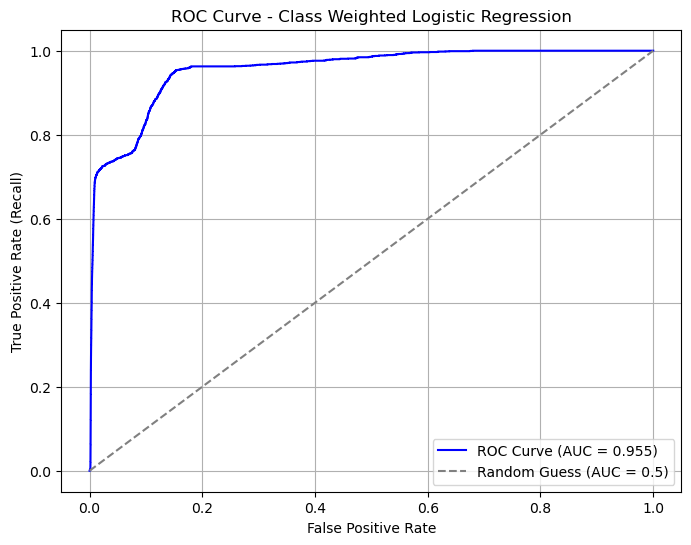

In [32]:
# Sampling Technique Comparison — Final Conclusion
# Across three imbalance-handling approaches (class weighting, SMOTE, random undersampling), model performance was statistically 
# indistinguishable both at the default threshold (0.5) and after threshold tuning (0.7) — precision, recall, and ROC-AUC varied by less 
# than 1 percentage point across all three methods. This indicates the underlying fraud signal in this dataset (driven primarily by 
# transaction amount, time-of-day, and merchant category) is strong enough that all three techniques converge to a similar decision 
# boundary.
# Given equivalent performance, class_weight='balanced' is the recommended approach
# it required no synthetic data generation (unlike SMOTE's ~2x training set expansion) and no data loss (unlike undersampling's ~99% 
# reduction in majority-class training data), making it the most computationally efficient choice without any performance tradeoff.

## Calculate ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_weighted_prob)
auc_score = roc_auc_score(Y_test, Y_pred_weighted_prob)

## Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Class Weighted Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()